In [1]:
# ============================================
# CELL 1: IMPORTS
# ============================================

import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from tqdm.auto import tqdm

In [2]:
# ============================================
# CELL 2: REPRODUCIBILITY
# ============================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed:", SEED)

Seed: 42


In [3]:
# ============================================
# CELL 3: DEVICE
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [4]:
# ============================================
# CELL 4: CONFIGURATION
# ============================================

IMG_SIZE = 256

BATCH_SIZE = 32

NUM_CLASSES = 4

NUM_WORKERS = 2

# Stage 1
HEAD_EPOCHS = 5
HEAD_LR = 1e-3

# Stage 2
FINETUNE_EPOCHS = 15
FINETUNE_LR = 1e-4

WEIGHT_DECAY = 1e-4

# Early stopping
PATIENCE = 4

# Focal Loss
FOCAL_GAMMA = 2.0

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

print("Configuration loaded.")

Configuration loaded.


In [5]:
# ============================================
# CELL 5: DATASET PATH
# ============================================

DATASET_ROOT = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

TRAIN_DIR = os.path.join(DATASET_ROOT, "Training")
TEST_DIR = os.path.join(DATASET_ROOT, "Testing")

print("Dataset root:", DATASET_ROOT)
print("Training directory:", TRAIN_DIR)
print("Testing directory:", TEST_DIR)

print("\nTraining folders:")
print(os.listdir(TRAIN_DIR))

print("\nTesting folders:")
print(os.listdir(TEST_DIR))

Dataset root: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
Training directory: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Testing directory: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing

Training folders:
['pituitary', 'notumor', 'meningioma', 'glioma']

Testing folders:
['pituitary', 'notumor', 'meningioma', 'glioma']


In [6]:
# ============================================
# CELL 6: VERIFY CLASS FOLDERS
# ============================================

for class_name in CLASS_NAMES:

    train_path = os.path.join(TRAIN_DIR, class_name)
    test_path = os.path.join(TEST_DIR, class_name)

    if not os.path.exists(train_path):
        raise FileNotFoundError(
            f"Training folder not found: {train_path}"
        )

    if not os.path.exists(test_path):
        raise FileNotFoundError(
            f"Testing folder not found: {test_path}"
        )

print("All class folders found successfully.")

All class folders found successfully.


In [7]:
# ============================================
# CELL 7: COLLECT IMAGE PATHS
# ============================================

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)


def collect_images(root_dir):
    
    image_paths = []
    labels = []

    for label, class_name in enumerate(CLASS_NAMES):

        class_dir = os.path.join(root_dir, class_name)

        for filename in os.listdir(class_dir):

            if filename.lower().endswith(VALID_EXTENSIONS):

                image_paths.append(
                    os.path.join(class_dir, filename)
                )

                labels.append(label)

    return image_paths, labels


train_paths_all, train_labels_all = collect_images(TRAIN_DIR)

test_paths, test_labels = collect_images(TEST_DIR)


print("Total training images:", len(train_paths_all))
print("Total testing images:", len(test_paths))

Total training images: 5600
Total testing images: 1600


In [8]:
# ============================================
# CELL 8: CLASS DISTRIBUTION
# ============================================

train_counts = pd.Series(train_labels_all).value_counts().sort_index()
test_counts = pd.Series(test_labels).value_counts().sort_index()

distribution_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Training": train_counts.values,
    "Testing": test_counts.values
})

display(distribution_df)

,Class,Training,Testing
0,glioma,1400,400
1,meningioma,1400,400
2,notumor,1400,400
3,pituitary,1400,400


In [9]:
# ============================================
# CELL 9: TRAIN / VALIDATION SPLIT
# ============================================

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths_all,
    train_labels_all,
    test_size=0.15,
    random_state=SEED,
    stratify=train_labels_all
)

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Testing images:", len(test_paths))

Training images: 4760
Validation images: 840
Testing images: 1600


In [11]:
# ============================================
# CELL 10: BRAIN CROP
# ============================================

def crop_brain(image, padding_ratio=0.10):
    
    if isinstance(image, Image.Image):
        img = np.array(image.convert("RGB"))
    else:
        img = np.array(image)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Separate foreground from black background
    _, thresh = cv2.threshold(
        gray,
        10,
        255,
        cv2.THRESH_BINARY
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # If no contour is found, return original image
    if not contours:
        return img

    # Largest foreground region
    largest_contour = max(
        contours,
        key=cv2.contourArea
    )

    x, y, w, h = cv2.boundingRect(
        largest_contour
    )

    pad_x = int(w * padding_ratio)
    pad_y = int(h * padding_ratio)

    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)

    x2 = min(
        img.shape[1],
        x + w + pad_x
    )

    y2 = min(
        img.shape[0],
        y + h + pad_y
    )

    cropped = img[y1:y2, x1:x2]

    return cropped

In [12]:
# ============================================
# CELL 11: CLAHE
# ============================================

def apply_clahe(image):
    
    if isinstance(image, Image.Image):
        img = np.array(image.convert("RGB"))
    else:
        img = np.array(image)

    # RGB -> LAB
    lab = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    enhanced_lab = cv2.merge(
        (l, a, b)
    )

    enhanced_rgb = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2RGB
    )

    return enhanced_rgb

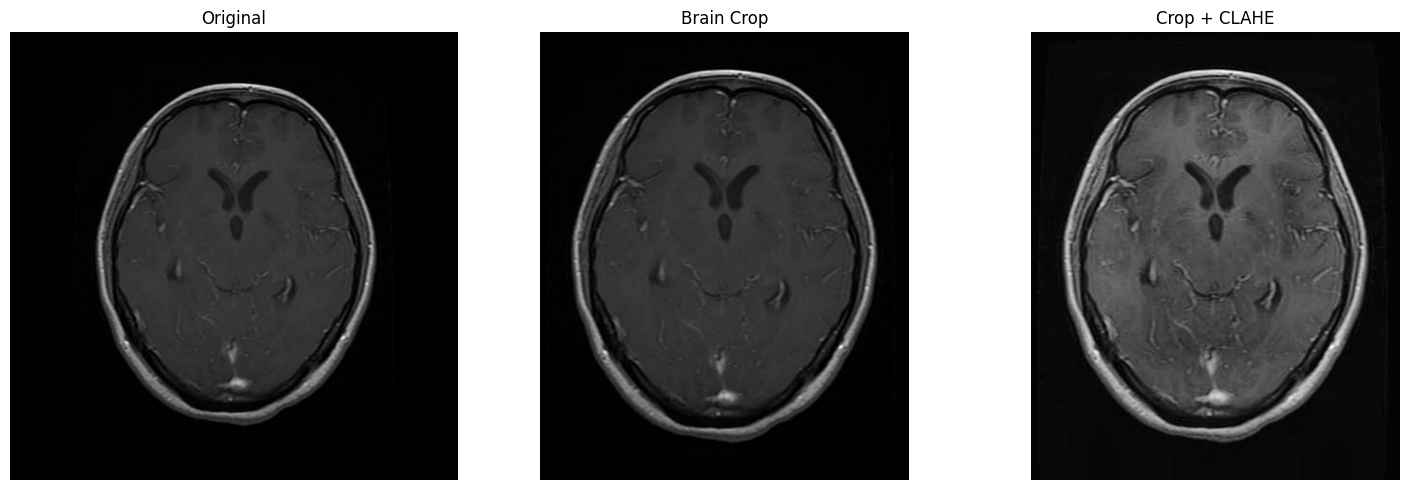

In [13]:
# ============================================
# CELL 12: PREPROCESSING VISUALIZATION
# ============================================

sample_path = train_paths[0]

original = Image.open(sample_path).convert("RGB")

cropped = crop_brain(original)

clahe_image = apply_clahe(cropped)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cropped)
plt.title("Brain Crop")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(clahe_image)
plt.title("Crop + CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# ============================================
# CELL 13: NORMAL TRAINING TRANSFORM
# ============================================

normal_train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [15]:
# ============================================
# CELL 14: GLIOMA-SPECIFIC TRANSFORM
# ============================================

glioma_train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.90, 1.10)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [16]:
# ============================================
# CELL 15: VALIDATION / TEST TRANSFORM
# ============================================

eval_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [17]:
# ============================================
# CELL 16: CUSTOM DATASET
# ============================================

class BrainMRIDataset(Dataset):

    def __init__(
        self,
        paths,
        labels,
        transform=None,
        glioma_transform=None,
        training=False
    ):

        self.paths = list(paths)
        self.labels = list(labels)

        self.transform = transform
        self.glioma_transform = glioma_transform

        self.training = training


    def __len__(self):

        return len(self.paths)


    def __getitem__(self, idx):

        path = self.paths[idx]

        label = int(self.labels[idx])

        # Load image
        image = Image.open(path).convert("RGB")

        # Brain crop
        image = crop_brain(image)

        # CLAHE
        image = apply_clahe(image)

        # Convert back to PIL
        image = Image.fromarray(image)

        # Targeted augmentation
        if self.training and label == 0:

            image = self.glioma_transform(image)

        else:

            image = self.transform(image)

        return image, label

In [19]:
# ============================================
# CELL 17: CREATE DATASETS
# ============================================

train_dataset = BrainMRIDataset(
    paths=train_paths,
    labels=train_labels,
    transform=normal_train_transform,
    glioma_transform=glioma_train_transform,
    training=True
)

val_dataset = BrainMRIDataset(
    paths=val_paths,
    labels=val_labels,
    transform=eval_transform,
    training=False
)

test_dataset = BrainMRIDataset(
    paths=test_paths,
    labels=test_labels,
    transform=eval_transform,
    training=False
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 4760
Validation dataset: 840
Test dataset: 1600


In [22]:
# ============================================
# CELL 18: DATALOADERS
# ============================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders created.")

DataLoaders created.


In [23]:
# ============================================
# CELL 19: CHECK BATCH
# ============================================

images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Image shape: torch.Size([32, 3, 256, 256])
Labels shape: torch.Size([32])
Labels: tensor([0, 1, 3, 3, 0, 2, 0, 0, 3, 0])


In [24]:
# ============================================
# CELL 20: EFFICIENTNET-B0
# ============================================

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)

# Original classifier input size
in_features = model.classifier[1].in_features

# Replace classifier
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(
        in_features,
        NUM_CLASSES
    )
)

model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 148MB/s]


Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


In [25]:
# ============================================
# CELL 21: FOCAL LOSS
# ============================================

class FocalLoss(nn.Module):

    def __init__(
        self,
        gamma=2.0,
        reduction="mean"
    ):

        super().__init__()

        self.gamma = gamma
        self.reduction = reduction


    def forward(self, logits, targets):

        # Standard cross entropy for each sample
        ce_loss = nn.functional.cross_entropy(
            logits,
            targets,
            reduction="none"
        )

        # Probability of correct class
        pt = torch.exp(-ce_loss)

        # Focal modulation
        focal_loss = (
            (1 - pt) ** self.gamma
        ) * ce_loss

        if self.reduction == "mean":

            return focal_loss.mean()

        elif self.reduction == "sum":

            return focal_loss.sum()

        else:

            return focal_loss

In [26]:
criterion = FocalLoss(
    gamma=FOCAL_GAMMA
)

print("Focal Loss gamma:", FOCAL_GAMMA)

Focal Loss gamma: 2.0


In [27]:
# ============================================
# CELL 22: MIXED PRECISION
# ============================================

amp_enabled = device.type == "cuda"

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=amp_enabled
)

print("AMP enabled:", amp_enabled)

AMP enabled: True


In [28]:
# ============================================
# CELL 23: METRIC FUNCTION
# ============================================

def calculate_metrics(labels, predictions):

    accuracy = accuracy_score(
        labels,
        predictions
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    macro_precision = precision_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall
    }

In [31]:
# ============================================
# CELL 24: TRAINING FUNCTION
# ============================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=amp_enabled
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        if amp_enabled:

            scaler.scale(loss).backward()

            scaler.step(optimizer)

            scaler.update()

        else:

            loss.backward()

            optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=loss.item()
        )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    metrics = calculate_metrics(
        all_labels,
        all_predictions
    )

    metrics["loss"] = epoch_loss

    return metrics

In [32]:
# ============================================
# CELL 25: VALIDATION FUNCTION
# ============================================

def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        progress_bar = tqdm(
            loader,
            desc="Validation",
            leave=False
        )

        for images, labels in progress_bar:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    metrics = calculate_metrics(
        all_labels,
        all_predictions
    )

    metrics["loss"] = epoch_loss

    return (
        metrics,
        all_labels,
        all_predictions
    )

In [33]:
# ============================================
# CELL 26: STAGE 1
# ============================================

for parameter in model.features.parameters():

    parameter.requires_grad = False


optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY
)

print("Stage 1: Feature extractor frozen.")
print("Learning rate:", HEAD_LR)

Stage 1: Feature extractor frozen.
Learning rate: 0.001


In [34]:
# ============================================
# CELL 27: TRAIN STAGE 1
# ============================================

best_stage1_f1 = -1.0

stage1_path = (
    "/kaggle/working/"
    "efficientnet_b0_focal_stage1.pth"
)

for epoch in range(HEAD_EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{HEAD_EPOCHS}"
    )

    train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_metrics, _, _ = evaluate(
        model,
        val_loader,
        criterion
    )

    print(
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Train F1: {train_metrics['macro_f1']:.4f}"
    )

    print(
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_stage1_f1:

        best_stage1_f1 = val_metrics["macro_f1"]

        torch.save(
            model.state_dict(),
            stage1_path
        )

        print("✓ Best Stage 1 model saved.")


Epoch 1/5


Training:   0%|          | 0/149 [00:00<?, ?it/s]

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

Train Loss: 0.2917 | Train Acc: 0.7840 | Train F1: 0.7849
Val Loss: 0.1803 | Val Acc: 0.8667 | Val F1: 0.8670
✓ Best Stage 1 model saved.

Epoch 2/5


Training:   0%|          | 0/149 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

Train Loss: 0.1596 | Train Acc: 0.8586 | Train F1: 0.8590
Val Loss: 0.1324 | Val Acc: 0.8810 | Val F1: 0.8797

Epoch 5/5


Training:   0%|          | 0/149 [00:00<?, ?it/s]

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

Train Loss: 0.1467 | Train Acc: 0.8687 | Train F1: 0.8688
Val Loss: 0.1269 | Val Acc: 0.8917 | Val F1: 0.8925
✓ Best Stage 1 model saved.


In [35]:
# ============================================
# CELL 28: LOAD BEST STAGE 1 MODEL
# ============================================

model.load_state_dict(
    torch.load(
        stage1_path,
        map_location=device
    )
)

print(
    "Best Stage 1 model loaded."
)

Best Stage 1 model loaded.


In [36]:
# ============================================
# CELL 29: STAGE 2 SETUP
# ============================================

for parameter in model.parameters():

    parameter.requires_grad = True


optimizer = optim.AdamW(
    model.parameters(),
    lr=FINETUNE_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=FINETUNE_EPOCHS
)

print("Entire EfficientNet is now trainable.")
print("Fine-tuning LR:", FINETUNE_LR)

Entire EfficientNet is now trainable.
Fine-tuning LR: 0.0001


In [37]:
# ============================================
# CELL 30: STAGE 2 TRAINING
# ============================================

best_val_f1 = -1.0

best_epoch = 0

patience_counter = 0

best_model_path = (
    "/kaggle/working/"
    "efficientnet_b0_focal_best.pth"
)

history = []


for epoch in range(FINETUNE_EPOCHS):

    print(
        f"\n{'='*60}"
    )

    print(
        f"Epoch {epoch + 1}/{FINETUNE_EPOCHS}"
    )

    print(
        f"Learning Rate: "
        f"{optimizer.param_groups[0]['lr']:.7f}"
    )

    # -------------------------------
    # Training
    # -------------------------------

    train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    # -------------------------------
    # Validation
    # -------------------------------

    val_metrics, val_labels_epoch, val_preds_epoch = evaluate(
        model,
        val_loader,
        criterion
    )

    # -------------------------------
    # Save history
    # -------------------------------

    history.append({

        "epoch": epoch + 1,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],

        "val_macro_recall": val_metrics["macro_recall"]
    })

    # -------------------------------
    # Print results
    # -------------------------------

    print(
        f"Train Loss: {train_metrics['loss']:.4f}"
    )

    print(
        f"Train Accuracy: "
        f"{train_metrics['accuracy']:.4f}"
    )

    print(
        f"Train Macro F1: "
        f"{train_metrics['macro_f1']:.4f}"
    )

    print(
        f"Val Loss: {val_metrics['loss']:.4f}"
    )

    print(
        f"Val Accuracy: "
        f"{val_metrics['accuracy']:.4f}"
    )

    print(
        f"Val Macro F1: "
        f"{val_metrics['macro_f1']:.4f}"
    )

    print(
        f"Val Macro Recall: "
        f"{val_metrics['macro_recall']:.4f}"
    )

    # -------------------------------
    # Check improvement
    # -------------------------------

    if val_metrics["macro_f1"] > best_val_f1:

        best_val_f1 = val_metrics["macro_f1"]

        best_epoch = epoch + 1

        patience_counter = 0

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("✓ New best model saved.")

    else:

        patience_counter += 1

        print(
            f"No improvement. "
            f"Patience: "
            f"{patience_counter}/{PATIENCE}"
        )

    # Update scheduler
    scheduler.step()

    # -------------------------------
    # Early stopping
    # -------------------------------

    if patience_counter >= PATIENCE:

        print(
            "\nEarly stopping triggered."
        )

        break


print("\nTraining complete.")
print("Best epoch:", best_epoch)
print("Best validation Macro F1:", best_val_f1)


Epoch 1/15
Learning Rate: 0.0001000


Training:   0%|          | 0/149 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a4a534b4d60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7a4a534b4d60>assert self._parent_pid == os.getpid(), 'can only test a child process'

Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers()  
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
       if w.is_alive(): 
  ^ ^ ^^ ^ ^^  ^^^^^^^^^^^^^^^^^^

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

Train Loss: 0.1106
Train Accuracy: 0.8958
Train Macro F1: 0.8956
Val Loss: 0.0571
Val Accuracy: 0.9476
Val Macro F1: 0.9478
Val Macro Recall: 0.9476
✓ New best model saved.

Epoch 2/15
Learning Rate: 0.0000989


...

Train Loss: 0.0061
Train Accuracy: 0.9947
Train Macro F1: 0.9947
Val Loss: 0.0246
Val Accuracy: 0.9845
Val Macro F1: 0.9845
Val Macro Recall: 0.9845
No improvement. Patience: 3/4

Epoch 15/15
Learning Rate: 0.0000011


Training:   0%|          | 0/149 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a4a534b4d60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a4a534b4d60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

Train Loss: 0.0052
Train Accuracy: 0.9935
Train Macro F1: 0.9935
Val Loss: 0.0247
Val Accuracy: 0.9845
Val Macro F1: 0.9845
Val Macro Recall: 0.9845
No improvement. Patience: 4/4

Early stopping triggered.

Training complete.
Best epoch: 11
Best validation Macro F1: 0.9856998157652548


In [38]:
# ============================================
# CELL 31: TRAINING CURVES
# ============================================

history_df = pd.DataFrame(history)

display(history_df)

,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,val_macro_recall
0,1,0.110627,0.895798,0.895599,0.057113,0.947619,0.947809,0.947619
1,2,0.056105,0.940336,0.940266,0.038735,0.961905,0.961780,0.961905
2,3,0.032226,0.965966,0.965967,0.027616,0.969048,0.968931,0.969048
3,4,0.025855,0.975000,0.975009,0.035359,0.967857,0.967946,0.967857
4,5,0.026765,0.971849,0.971856,0.032537,0.973810,0.973793,0.973810
5,6,0.016645,0.983193,0.983209,0.027861,0.978571,0.978531,0.978571
6,7,0.013202,0.984454,0.984462,0.030828,0.977381,0.977391,0.977381
7,8,0.011401,0.986765,0.986771,0.023807,0.983333,0.983329,0.983333
8,9,0.009083,0.991176,0.991176,0.028120,0.979762,0.979782,0.979762
9,10,0.008360,0.991176,0.991175,0.024101,0.984524,0.984512,0.984524


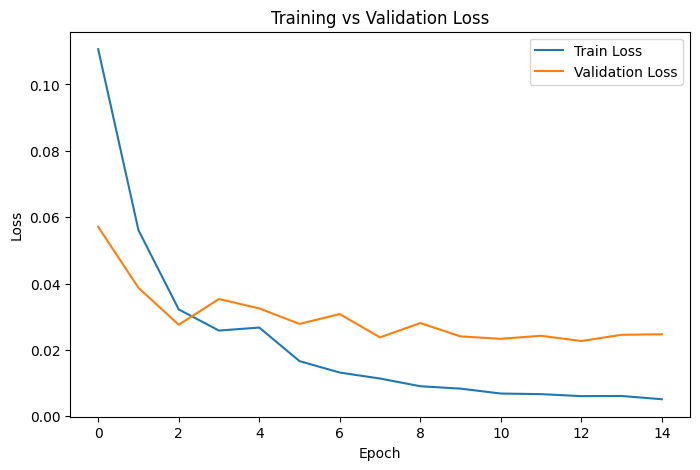

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

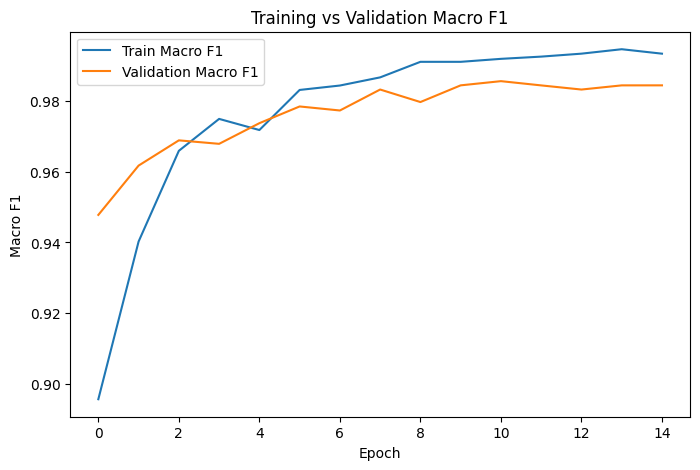

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["train_macro_f1"],
    label="Train Macro F1"
)

plt.plot(
    history_df["val_macro_f1"],
    label="Validation Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Training vs Validation Macro F1")

plt.legend()

plt.show()

In [41]:
# ============================================
# CELL 32: LOAD BEST MODEL
# ============================================

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.eval()

print("Best model loaded.")

Best model loaded.


In [42]:
# ============================================
# CELL 33: VALIDATION EVALUATION
# ============================================

val_metrics, val_labels, val_preds = evaluate(
    model,
    val_loader,
    criterion
)

print("Validation Results")
print("=" * 50)

for key, value in val_metrics.items():

    print(
        f"{key}: {value:.4f}"
    )

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

Validation Results
accuracy: 0.9857
macro_f1: 0.9857
macro_precision: 0.9857
macro_recall: 0.9857
loss: 0.0234


In [43]:
# ============================================
# CELL 34: VALIDATION CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        val_labels,
        val_preds,
        target_names=CLASS_NAMES,
        digits=4
    )
)

              precision    recall  f1-score   support

      glioma     0.9952    0.9810    0.9880       210
  meningioma     0.9761    0.9714    0.9737       210
     notumor     0.9858    0.9952    0.9905       210
   pituitary     0.9858    0.9952    0.9905       210

    accuracy                         0.9857       840
   macro avg     0.9857    0.9857    0.9857       840
weighted avg     0.9857    0.9857    0.9857       840



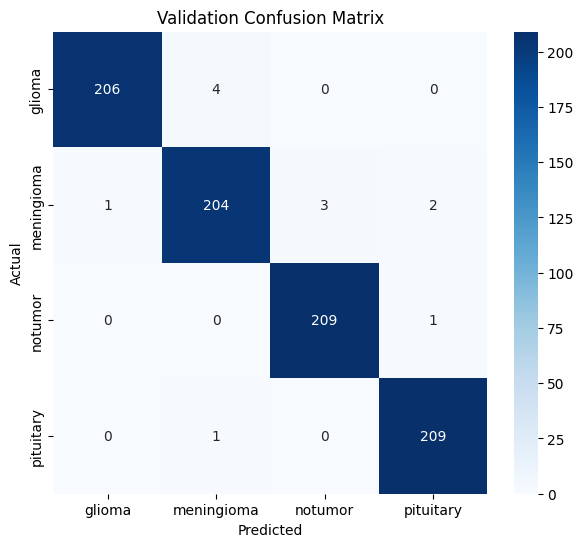

In [44]:
# ============================================
# CELL 35: VALIDATION CONFUSION MATRIX
# ============================================

val_cm = confusion_matrix(
    val_labels,
    val_preds
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    val_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Validation Confusion Matrix"
)

plt.show()

In [45]:
# ============================================
# CELL 36: GLIOMA ANALYSIS
# ============================================

glioma_index = 0

glioma_total = sum(
    label == glioma_index
    for label in val_labels
)

glioma_correct = sum(
    true == glioma_index and pred == glioma_index
    for true, pred in zip(
        val_labels,
        val_preds
    )
)

glioma_missed = (
    glioma_total - glioma_correct
)

glioma_recall = (
    glioma_correct / glioma_total
)

print("Glioma Analysis")
print("=" * 50)

print("Total glioma:", glioma_total)
print("Correct:", glioma_correct)
print("Missed:", glioma_missed)

print(
    f"Recall: {glioma_recall:.4f}"
)

print(
    f"Recall: {glioma_recall * 100:.2f}%"
)

Glioma Analysis
Total glioma: 210
Correct: 206
Missed: 4
Recall: 0.9810
Recall: 98.10%


In [46]:
# ============================================
# CELL 37: GLIOMA ERROR BREAKDOWN
# ============================================

glioma_errors = []

for true_label, pred_label in zip(
    val_labels,
    val_preds
):

    if (
        true_label == 0
        and pred_label != 0
    ):

        glioma_errors.append(
            CLASS_NAMES[pred_label]
        )


glioma_error_counts = pd.Series(
    glioma_errors
).value_counts()


print(
    "Where are actual gliomas being predicted?"
)

display(glioma_error_counts)

Where are actual gliomas being predicted?


meningioma    4
Name: count, dtype: int64

In [47]:
# ============================================
# CELL 38: FINAL TEST EVALUATION
# ============================================

test_metrics, test_labels_final, test_preds_final = evaluate(
    model,
    test_loader,
    criterion
)

print("FINAL TEST RESULTS")
print("=" * 50)

for key, value in test_metrics.items():

    print(
        f"{key}: {value:.4f}"
    )

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

FINAL TEST RESULTS
accuracy: 0.9550
macro_f1: 0.9540
macro_precision: 0.9581
macro_recall: 0.9550
loss: 0.1819


In [48]:
# ============================================
# CELL 39: FINAL TEST CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        test_labels_final,
        test_preds_final,
        target_names=CLASS_NAMES,
        digits=4
    )
)

              precision    recall  f1-score   support

      glioma     1.0000    0.8350    0.9101       400
  meningioma     0.9037    0.9850    0.9426       400
     notumor     0.9412    1.0000    0.9697       400
   pituitary     0.9877    1.0000    0.9938       400

    accuracy                         0.9550      1600
   macro avg     0.9581    0.9550    0.9540      1600
weighted avg     0.9581    0.9550    0.9540      1600



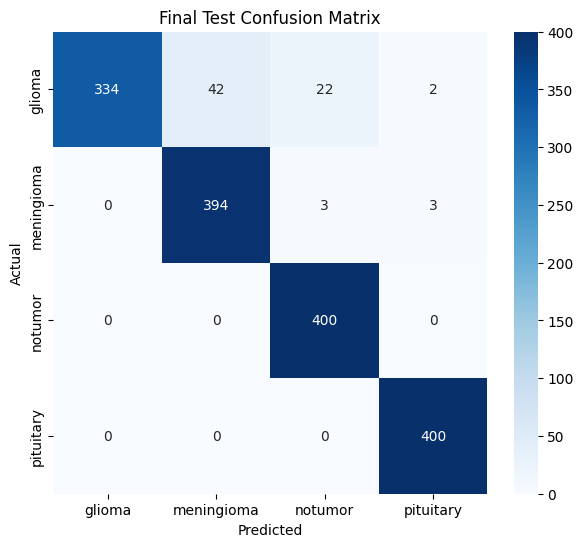

In [49]:
# ============================================
# CELL 40: FINAL TEST CONFUSION MATRIX
# ============================================

test_cm = confusion_matrix(
    test_labels_final,
    test_preds_final
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Final Test Confusion Matrix"
)

plt.show()

In [50]:
# ============================================
# CELL 41: FINAL GLIOMA TEST RECALL
# ============================================

test_glioma_total = sum(
    label == 0
    for label in test_labels_final
)

test_glioma_correct = sum(
    true == 0 and pred == 0
    for true, pred in zip(
        test_labels_final,
        test_preds_final
    )
)

test_glioma_recall = (
    test_glioma_correct /
    test_glioma_total
)

print(
    f"Test Glioma Recall: "
    f"{test_glioma_recall * 100:.2f}%"
)

print(
    "Glioma correctly classified:",
    test_glioma_correct
)

print(
    "Glioma missed:",
    test_glioma_total -
    test_glioma_correct
)

Test Glioma Recall: 83.50%
Glioma correctly classified: 334
Glioma missed: 66


In [53]:
# ============================================
# CELL 43: DATASET WITH PATHS
# ============================================

class BrainMRIDatasetWithPaths(Dataset):

    def __init__(
        self,
        paths,
        labels,
        transform
    ):

        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform


    def __len__(self):

        return len(self.paths)


    def __getitem__(self, idx):

        path = self.paths[idx]

        label = int(self.labels[idx])

        image = Image.open(
            path
        ).convert("RGB")

        image = crop_brain(image)

        image = apply_clahe(image)

        image = Image.fromarray(image)

        image = self.transform(image)

        return image, label, path

In [55]:
# ============================================
# CELL 44: VALIDATION PATH DATASET
# ============================================

val_path_dataset = BrainMRIDatasetWithPaths(
    val_paths,
    val_labels,
    eval_transform
)

val_path_loader = DataLoader(
    val_path_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [59]:
# ============================================
# CELL 45: VALIDATION PREDICTIONS WITH PATHS
# ============================================

model.eval()

all_val_labels = []
all_val_preds = []
all_val_paths = []

with torch.no_grad():

    for images, labels, paths in tqdm(
        val_path_loader,
        desc="Collecting validation predictions"
    ):

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(
            dim=1
        )

        all_val_labels.extend(
            labels.numpy()
        )

        all_val_preds.extend(
            predictions.cpu().numpy()
        )

        all_val_paths.extend(paths)

In [60]:
# ============================================
# CELL 46: HARD GLIOMA EXAMPLES
# ============================================

hard_glioma = []

for path, true_label, pred_label in zip(
    all_val_paths,
    all_val_labels,
    all_val_preds
):

    if (
        true_label == 0
        and pred_label != 0
    ):

        hard_glioma.append({
            "path": path,
            "actual": CLASS_NAMES[true_label],
            "predicted": CLASS_NAMES[pred_label]
        })


print(
    "Misclassified validation gliomas:",
    len(hard_glioma)
)

for item in hard_glioma[:20]:

    print(
        item["actual"],
        "→",
        item["predicted"],
        "|",
        item["path"]
    )

Misclassified validation gliomas: 4
glioma → meningioma | /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1106.jpg
glioma → meningioma | /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/glioma/Tr-gl_976.jpg
glioma → meningioma | /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1345.jpg
glioma → meningioma | /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/glioma/Tr-gl_1153.jpg


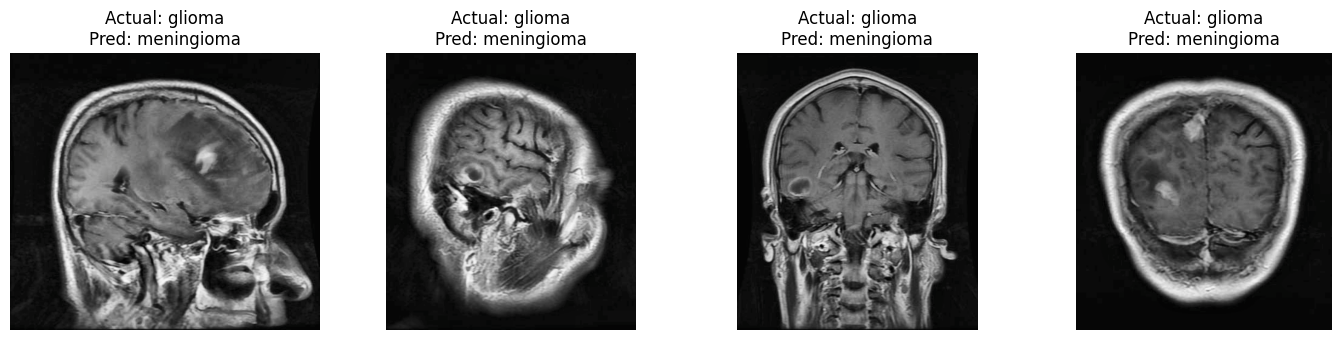

In [61]:
# ============================================
# CELL 47: VISUALIZE HARD GLIOMA EXAMPLES
# ============================================

num_images = min(
    16,
    len(hard_glioma)
)

cols = 4

rows = int(
    np.ceil(num_images / cols)
)

plt.figure(
    figsize=(14, 3.5 * rows)
)

for i in range(num_images):

    item = hard_glioma[i]

    image = Image.open(
        item["path"]
    ).convert("RGB")

    processed = crop_brain(image)

    processed = apply_clahe(
        processed
    )

    plt.subplot(
        rows,
        cols,
        i + 1
    )

    plt.imshow(processed)

    plt.title(
        f"Actual: {item['actual']}\n"
        f"Pred: {item['predicted']}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [63]:
# ============================================
# CELL 48: GRAD-CAM
# ============================================

class GradCAM:

    def __init__(
        self,
        model,
        target_layer
    ):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            target_layer.register_forward_hook(
                self.save_activation
            )
        )

        self.backward_handle = (
            target_layer.register_full_backward_hook(
                self.save_gradient
            )
        )


    def save_activation(
        self,
        module,
        input,
        output
    ):

        self.activations = output


    def save_gradient(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[0]


    def generate(
        self,
        image,
        target_class
    ):

        self.model.zero_grad()

        output = self.model(
            image.unsqueeze(0).to(device)
        )

        score = output[
            0,
            target_class
        ]

        score.backward()

        activations = (
            self.activations
            .detach()
            .cpu()
            .squeeze(0)
        )

        gradients = (
            self.gradients
            .detach()
            .cpu()
            .squeeze(0)
        )

        # Average gradients over spatial dimensions
        weights = gradients.mean(
            dim=(1, 2)
        )

        # Weighted feature maps
        cam = (
            weights[:, None, None]
            * activations
        ).sum(dim=0)

        # ReLU
        cam = torch.relu(cam)

        # Normalize
        cam = cam.numpy()

        cam = cam - cam.min()

        cam = cam / (
            cam.max() + 1e-8
        )

        return cam


    def remove_hooks(self):

        self.forward_handle.remove()

        self.backward_handle.remove()

In [66]:
# ============================================
# CELL 49: CREATE GRAD-CAM
# ============================================

target_layer = model.features[-1]

grad_cam = GradCAM(
    model,
    target_layer
)

print("Grad-CAM ready.")

Grad-CAM ready.


In [79]:
# ============================================
# CELL 50: GRAD-CAM VISUALIZATION
# ============================================

def show_gradcam(
    image_path,
    true_class,
    predicted_class
):

    original = Image.open(
        image_path
    ).convert("RGB")

    processed = crop_brain(
        original
    )

    processed = apply_clahe(
        processed
    )

    processed_pil = Image.fromarray(
        processed
    )

    tensor = eval_transform(
        processed_pil
    )

    # Generate CAM
    cam = grad_cam.generate(
        tensor,
        predicted_class
    )

    # Resize CAM
    cam_resized = cv2.resize(
        cam,
        (
            processed.shape[1],
            processed.shape[0]
        )
    )

    heatmap = np.uint8(
        255 * cam_resized
    )

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    overlay = (
        0.5 * processed
        + 0.5 * heatmap
    )

    overlay = np.uint8(
        np.clip(
            overlay,
            0,
            255
        )
    )

    plt.figure(
        figsize=(15, 5)
    )

    plt.subplot(1, 3, 1)

    plt.imshow(processed)

    plt.title(
        f"Original\n"
        f"Actual: {CLASS_NAMES[true_class]}"
    )

    plt.axis("off")


    plt.subplot(1, 3, 2)

    plt.imshow(cam_resized)

    plt.title(
        f"Grad-CAM\n"
        f"Predicted: {CLASS_NAMES[predicted_class]}"
    )

    plt.axis("off")


    plt.subplot(1, 3, 3)

    plt.imshow(overlay)

    plt.title("Overlay")

    plt.axis("off")

    plt.tight_layout()

    plt.show()

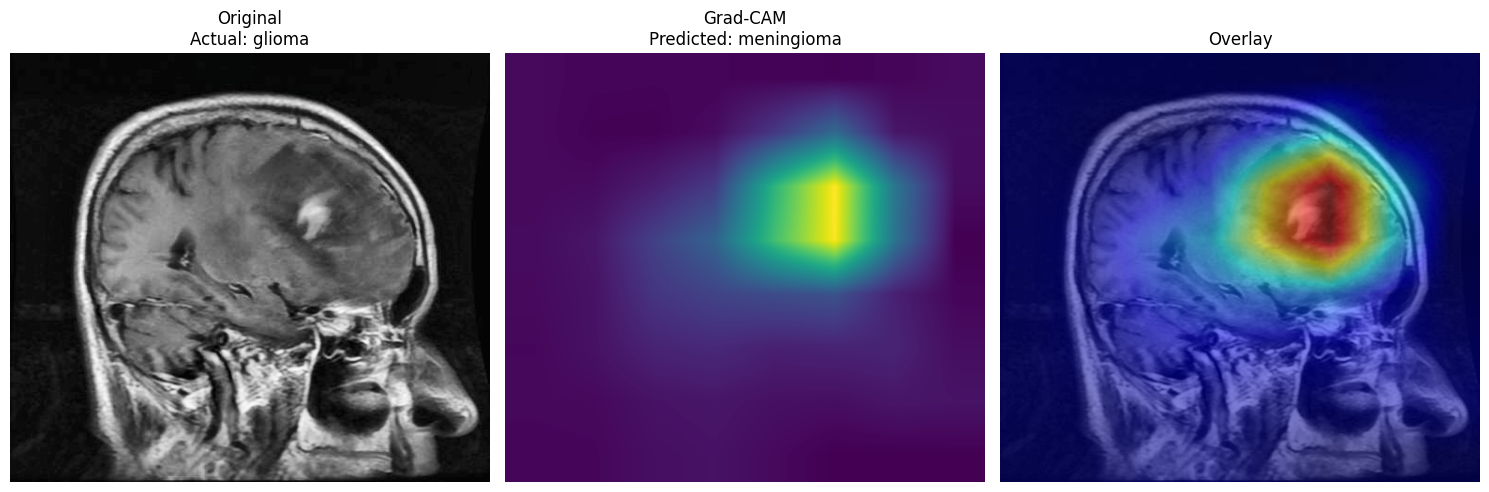

In [80]:
# ============================================
# CELL 51: HARD GLIOMA GRAD-CAM
# ============================================

if len(hard_glioma) > 0:

    example = hard_glioma[0]

    show_gradcam(
        image_path=example["path"],
        true_class=0,
        predicted_class=CLASS_NAMES.index(
            example["predicted"]
        )
    )

else:

    print(
        "No misclassified glioma found "
        "in validation set."
    )

In [81]:
# ============================================
# CELL 52: SAVE MODEL
# ============================================

final_model_path = (
    "/kaggle/working/"
    "brain_tumor_efficientnet_b0_focal.pth"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),

        "class_names": CLASS_NAMES,

        "img_size": IMG_SIZE,

        "architecture": "efficientnet_b0",

        "loss": "focal_loss",

        "focal_gamma": FOCAL_GAMMA
    },
    final_model_path
)

print(
    "Model saved to:",
    final_model_path
)

Model saved to: /kaggle/working/brain_tumor_efficientnet_b0_focal.pth


In [ ]:
# ============================================
# CELL 53: FINAL SUMMARY
# ============================================

print("=" * 60)
print("FINAL BRAIN TUMOR CLASSIFICATION RESULTS")
print("=" * 60)

print(
    f"Accuracy     : "
    f"{test_metrics['accuracy'] * 100:.2f}%"
)

print(
    f"Macro F1     : "
    f"{test_metrics['macro_f1'] * 100:.2f}%"
)

print(
    f"Macro Recall : "
    f"{test_metrics['macro_recall'] * 100:.2f}%"
)

print(
    f"Macro Prec.  : "
    f"{test_metrics['macro_precision'] * 100:.2f}%"
)

print(
    f"Glioma Recall: "
    f"{test_glioma_recall * 100:.2f}%"
)

print("=" * 60)